In [1]:
#C:/Users/alim10/mini/BiSe_232deg_38p7nm_static_6.h5

In [1]:
#Importing libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import h5py

In [2]:
file = 'BiSe_232deg_38p7nm_static_6.h5'

In [3]:
def structure(name, obj):
    print(name)
with h5py.File(file, 'r') as f:
    f.visititems(structure)

scan0
scan0/image
scan0/lastimage
scan0/positions
scan0/temperatures


In [8]:
import h5py
import numpy as np
import pandas as pd

# 1. Open the file and extract the raw data
with h5py.File("BiSe_232deg_38p7nm_static_6.h5", "r") as f:
    data = f["scan0/image"][:]
    factors = f["scan0/image"].attrs["DIMENSION_FACTORS"]
    offsets = f["scan0/image"].attrs["DIMENSION_OFFSETS"]

# 2. Reconstruct the actual Energy (X) and Angle (Y) values
angles = offsets[2] + np.arange(data.shape[2]) * factors[2]
energies = offsets[3] + np.arange(data.shape[3]) * factors[3]

# 3. Smash the 4D repetitions down into a clean 2D grid (Angles x Energies)
intensity_matrix = np.sum(data, axis=(0, 1))

# 4. Turn it into a table with nice row/column labels and save to CSV
df = pd.DataFrame(intensity_matrix, index=angles, columns=energies)
df.to_csv("arpes_data_grid.csv")

print("Done! Saved as arpes_data_grid.csv")

Done! Saved as arpes_data_grid.csv


In [13]:
df= 'arpes_data_grid.csv'
df1=pd.read_csv(df)
df1

,Unnamed: 0,-25.06215916,-25.0553586025,-25.048558045,-25.0417574875,-25.03495693,-25.0281563725,-25.021355815,-25.0145552575,-25.0077547,...,-19.254483055,-19.2476824975,-19.24088194,-19.2340813825,-19.227280825,-19.2204802675,-19.21367971,-19.2068791525,-19.200078595,-19.1932780375
0,24.502104,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,24.584881,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,24.667658,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,24.750436,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,24.833213,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
571,71.767986,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
572,71.850763,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
573,71.933541,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
574,72.016318,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
#Append method

In [7]:
def get_all_paths(name):
    all_paths.append(name)
all_paths = []
with h5py.File(file, 'r') as f:
    f.visit(get_all_paths)
for path in all_paths:
    print(path)

scan0
scan0/image
scan0/lastimage
scan0/positions
scan0/temperatures


In [ ]:
#Reading

In [6]:
file_path = 'BiSe_232deg_38p7nm_static_6.h5'

with h5py.File(file_path, 'r') as f:
    for path in ['scan0/image', 'scan0/lastimage', 'scan0/positions', 'scan0/temperatures']:
        data = f[path][()] # Load data into memory
        
        print(f"--- Path: {path} ---")
        print(f"Shape: {data.shape}")
        print(f"Type:  {data.dtype}")
        print(f"Size:  {data.size}")     
        # If it's a small array (like positions or temps), print it all
        # If it's a big image, just print the max/min/mean
        if data.size < 50:
            print(f"Value: {data}")
        else:
            print(f"Stats: Min={data.min()}, Max={data.max()}, Mean={data.mean():.2f}")
        print("-" * 30)

--- Path: scan0/image ---
Shape: (20, 1, 576, 864)
Type:  uint16
Size:  9953280
Stats: Min=0, Max=11, Mean=0.13
------------------------------
--- Path: scan0/lastimage ---
Shape: (576, 864)
Type:  uint16
Size:  497664
Stats: Min=0, Max=7, Mean=0.13
------------------------------
--- Path: scan0/positions ---
Shape: (1,)
Type:  float64
Size:  1
Value: [-140500.]
------------------------------
--- Path: scan0/temperatures ---
Shape: (1, 20)
Type:  float64
Size:  20
Value: [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
------------------------------


In [16]:
filename = "BiSe_232deg_38p7nm_static_6.h5"
with h5py.File(filename, 'r') as f:
    # Read the data into a variable called 'data'
    data = f['scan0/image'][:]
    print(data.shape) # This will print: (20, 1, 576, 864)

(20, 1, 576, 864)


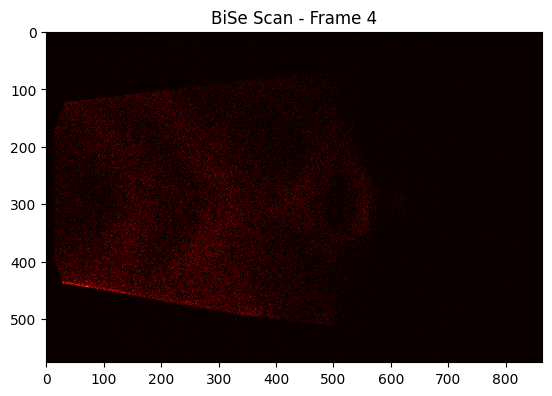

In [17]:
import h5py
import matplotlib.pyplot as plt

file_path = 'BiSe_232deg_38p7nm_static_6.h5'

with h5py.File(file_path, 'r') as f:
    images = f['scan0/image'][()] 
    
    # Let's look at the 5th frame as an example
    # We use [4] for the 5th frame, and [0] to bypass that middle '1' dimension
    frame_index = 4 
    img = images[frame_index, 0, :, :] 

    plt.imshow(img, cmap='hot')
    plt.title(f"BiSe Scan - Frame {frame_index}")
    plt.savefig('1')
    plt.show()

In [18]:
with h5py.File(filename, 'r') as f:
    data = f['scan0/image'][:]
    
    # Get the math formulas to convert pixels to real units
    factors = f['scan0/image'].attrs['DIMENSION_FACTORS']
    offsets = f['scan0/image'].attrs['DIMENSION_OFFSETS']
    
    # Calculate the Angle values (the Y-axis, which is dimension index 2)
    angle_offset = offsets[2]
    angle_factor = factors[2]
    num_angles = data.shape[2] # This is 576
    # Create an array of actual angle values: start_value + (pixel_number * step_size)
    angles = angle_offset + np.arange(num_angles) * angle_factor
    
    # Calculate the Energy values (the X-axis, which is dimension index 3)
    energy_offset = offsets[3]
    energy_factor = factors[3]
    num_energies = data.shape[3] # This is 864
    energies = energy_offset + np.arange(num_energies) * energy_factor

In [20]:
with h5py.File(filename, 'r') as f:
    data = f['scan0/image'][:]
    
    # Get the math formulas to convert pixels to real units
    factors = f['scan0/image'].attrs['DIMENSION_FACTORS']
    offsets = f['scan0/image'].attrs['DIMENSION_OFFSETS']
    
    # Calculate the Angle values (the Y-axis, which is dimension index 2)
    angle_offset = offsets[2]
    angle_factor = factors[2]
    num_angles = data.shape[2] # This is 576
    # Create an array of actual angle values: start_value + (pixel_number * step_size)
    angles = angle_offset + np.arange(num_angles) * angle_factor
    
    # Calculate the Energy values (the X-axis, which is dimension index 3)
    energy_offset = offsets[3]
    energy_factor = factors[3]
    num_energies = data.shape[3] # This is 864
    energies = energy_offset + np.arange(num_energies) * energy_factor

In [21]:
# Sum across the first two dimensions
# The new shape will just be (576, 864)
data_2d = np.sum(data, axis=(0, 1))

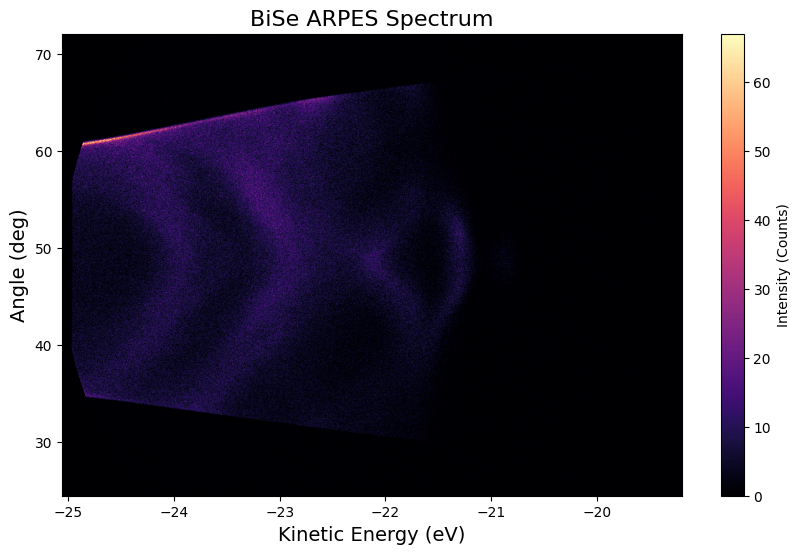

In [22]:
# 1. Create a blank canvas
plt.figure(figsize=(10, 6))

# 2. Tell the plot the physical boundaries [left, right, bottom, top]
extent = [energies[0], energies[-1], angles[-1], angles[0]]

# 3. Paint the data as an image using the 'magma' color map
im = plt.imshow(data_2d, aspect='auto', cmap='magma', extent=extent)

# 4. Add a colorbar to show what the colors mean
plt.colorbar(im, label='Intensity (Counts)')

# 5. Add text labels so people know what they are looking at
plt.xlabel('Kinetic Energy (eV)', fontsize=14)
plt.ylabel('Angle (deg)', fontsize=14)
plt.title('BiSe ARPES Spectrum', fontsize=16)

# 6. Invert the Y-axis (standard for this kind of data)
plt.gca().invert_yaxis()

# 7. Show the plot on your screen
plt.show()

In [24]:
import pandas as pd

# Load your clean CSV file
df = pd.read_csv("arpes_data_grid.csv", index_col=0)

# See how big the spreadsheet is
print("Spreadsheet shape:", df.shape) 
# This will print: Spreadsheet shape: (576, 864)

Spreadsheet shape: (576, 864)


In [25]:
# Grab the very first row (index 0)
first_angle_row = df.iloc[0]

print("Energy values (Columns):", first_angle_row.index)
print("Electron counts:", first_angle_row.values)

Energy values (Columns): Index(['-25.06215916', '-25.0553586025', '-25.048558045', '-25.0417574875',
       '-25.03495693', '-25.0281563725', '-25.021355815', '-25.0145552575',
       '-25.0077547', '-25.0009541425',
       ...
       '-19.254483055', '-19.2476824975', '-19.24088194', '-19.2340813825',
       '-19.227280825', '-19.2204802675', '-19.21367971', '-19.2068791525',
       '-19.200078595', '-19.1932780375'],
      dtype='object', length=864)
Electron counts: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 

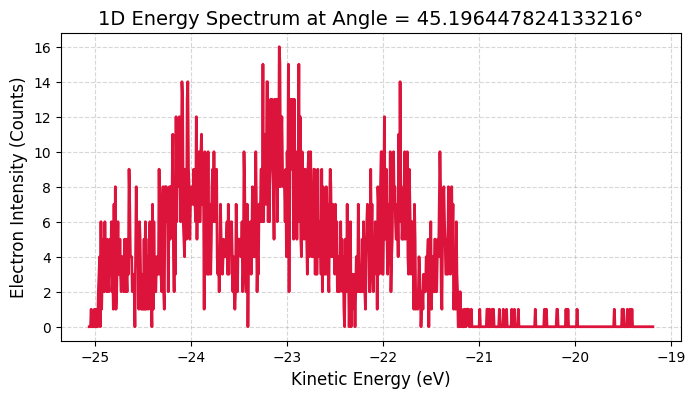

In [26]:
import matplotlib.pyplot as plt

# 1. Pick a row from the middle of the dataset
sample_row = df.iloc[250]
angle_value = sample_row.name # Gets the actual angle number (e.g., 40.5 deg)

# 2. Get the X-axis (Energies) and Y-axis (Counts)
# Note: We convert headers from text strings back to numbers
energies = sample_row.index.astype(float) 
counts = sample_row.values

# 3. Create a line plot
plt.figure(figsize=(8, 4))
plt.plot(energies, counts, color="crimson", linewidth=2)

# 4. Label your graph cleanly
plt.xlabel("Kinetic Energy (eV)", fontsize=12)
plt.ylabel("Electron Intensity (Counts)", fontsize=12)
plt.title(f"1D Energy Spectrum at Angle = {angle_value}°", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

In [27]:
# Find the highest number of counts in the entire spreadsheet
max_counts = df.max().max()
print(f"The highest electron count recorded is: {max_counts}")

# Find which Energy column holds that peak
peak_energy = df.max().idxmax()
print(f"The peak occurs at Kinetic Energy: {peak_energy} eV")

The highest electron count recorded is: 67
The peak occurs at Kinetic Energy: -24.6745273825 eV


Found 1 scans: ['scan0']
Final shape for DataFrame: 576 rows x 864 columns


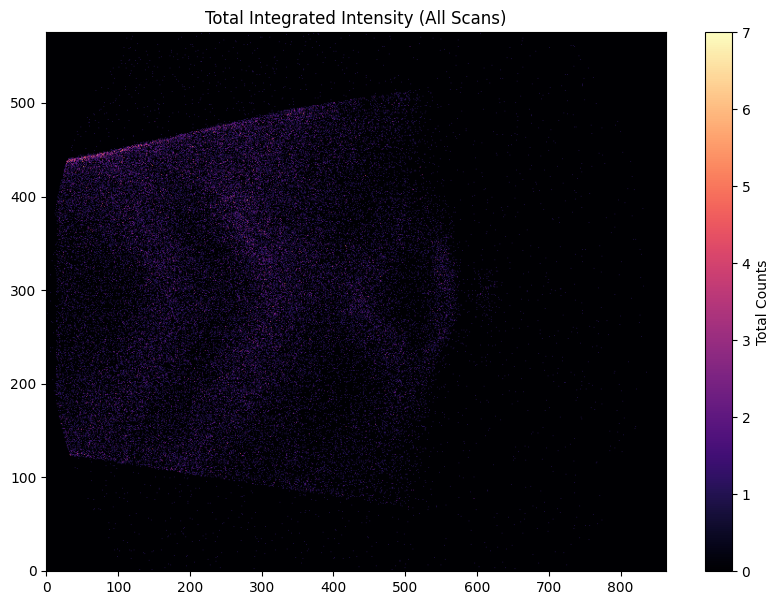

In [11]:
import pandas as pd
import numpy as np
import h5py
import matplotlib.pyplot as plt

file_path = 'BiSe_232deg_38p7nm_static_6.h5'

with h5py.File(file_path, 'r') as f:
    # 1. Identify all scan groups (scan0, scan1, etc.)
    scans = [key for key in f.keys() if key.startswith('scan')]
    print(f"Found {len(scans)} scans: {scans}")

    # 2. Initialize a zero-array for the total sum
    # We'll use the shape of the first scan to set it up
    first_img = np.squeeze(f[f"{scans[0]}/image"][()])
    total_intensity = np.zeros_like(first_img, dtype=np.float64)

    # 3. Accumulate the data
    for s in scans:
        img_data = np.squeeze(f[f"{s}/image"][()])
        # Ensure shapes match before adding
        if img_data.shape == total_intensity.shape:
            total_intensity += img_data

   # ... (inside the 'with' block after the loop)

# 4. Force the data to be 2D
# This removes any lingering dimensions of length 1 (like 1x576x864 -> 576x864)
total_intensity = np.squeeze(total_intensity)

if total_intensity.ndim != 2:
    # If there are still extra dimensions (e.g. 3D stack), take the first slice
    print(f"Warning: Data is {total_intensity.ndim}D. Slicing to 2D.")
    total_intensity = total_intensity[0]

rows, cols = total_intensity.shape 
print(f"Final shape for DataFrame: {rows} rows x {cols} columns")

# Now this will work perfectly
r_coords, c_coords = np.indices((rows, cols))

df_summed = pd.DataFrame({
    'Energy_Idx': r_coords.ravel(),
    'Angle_Idx': c_coords.ravel(),
    'Intensity': total_intensity.ravel()
})
# 5. Visualize the "Cleaned" Result
plot_data = df_summed.pivot(index='Energy_Idx', columns='Angle_Idx', values='Intensity')
plt.figure(figsize=(10, 7))
plt.imshow(plot_data, aspect='auto', cmap='magma', origin='lower')
plt.title("Total Integrated Intensity (All Scans)")
plt.colorbar(label='Total Counts')
plt.show()

In [28]:
import h5py
import numpy as np
import scipy.ndimage as ndimage
import matplotlib.pyplot as plt

# 1. Open file and load real physical grids
with h5py.File("BiSe_232deg_38p7nm_static_6.h5", "r") as f:
    data = f["scan0/image"][:]
    factors = f["scan0/image"].attrs["DIMENSION_FACTORS"]
    offsets = f["scan0/image"].attrs["DIMENSION_OFFSETS"]

angles = offsets[2] + np.arange(data.shape[2]) * factors[2]
energies = offsets[3] + np.arange(data.shape[3]) * factors[3]

# Smash 4D down into 2D and apply gentle smoothing to clear up noise
raw_matrix = np.sum(data, axis=(0, 1))
smoothed_matrix = ndimage.gaussian_filter(raw_matrix, sigma=1.5)
extent = [energies[0], energies[-1], angles[0], angles[-1]]

# --- PLOT 1: 2D Band Structure Heatmap ---
plt.figure(figsize=(7, 5))
plt.imshow(smoothed_matrix, aspect='auto', cmap='afmhot', extent=extent, origin='lower')
plt.colorbar(label='Photoelectron Intensity')
plt.xlabel('Kinetic Energy (eV)')
plt.ylabel('Angle (deg)')
plt.title('Plot 1: 2D Electronic Band Structure Map')
plt.savefig('plot_2d_bandstructure.png', dpi=300)
plt.show()

# --- PLOT 2: EDC Waterfall Plot ---
plt.figure(figsize=(7, 7))
for idx in np.arange(100, 500, 30):  # Select subsets of angles to avoid crowd
    offset = (idx - 100) * 0.5
    plt.plot(energies, smoothed_matrix[idx, :] + offset, label=f'{angles[idx]:.1f}°')
plt.xlabel('Kinetic Energy (eV)')
plt.ylabel('Intensity + Offset')
plt.title('Plot 2: Energy Distribution Curves (EDC Waterfall)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Angles")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('plot_edc_waterfall.png', dpi=300)
plt.show()

# --- PLOT 3: MDC Slices ---
plt.figure(figsize=(7, 5))
for idx in [200, 250, 294, 350, 400]:  # Choose key energy slices
    plt.plot(angles, smoothed_matrix[:, idx], label=f'E = {energies[idx]:.2f} eV')
plt.xlabel('Angle (deg)')
plt.ylabel('Intensity (Counts)')
plt.title('Plot 3: Momentum Distribution Curves (MDC Slices)')
plt.legend(title="Energy Levels")
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('plot_mdc_slices.png', dpi=300)
plt.show()

# --- PLOT 4: Second Derivative Contour Enhancer ---
d2_matrix = ndimage.gaussian_filter(raw_matrix, sigma=2.0)
d2_energy = np.diff(d2_matrix, n=2, axis=1)
d2_padded = np.pad(d2_energy, ((0,0), (1,1)), mode='edge')

plt.figure(figsize=(7, 5))
plt.imshow(-d2_padded, aspect='auto', cmap='gray', extent=extent, origin='lower', vmin=0)
plt.xlabel('Kinetic Energy (eV)')
plt.ylabel('Angle (deg)')
plt.title('Plot 4: Negative Second Derivative Map ($-\\partial^2I/\\partial E^2$)')
plt.savefig('plot_second_derivative.png', dpi=300)
plt.show()

print("All 4 publication plots have been successfully saved to your folder!")

All 4 publication plots have been successfully saved to your folder!


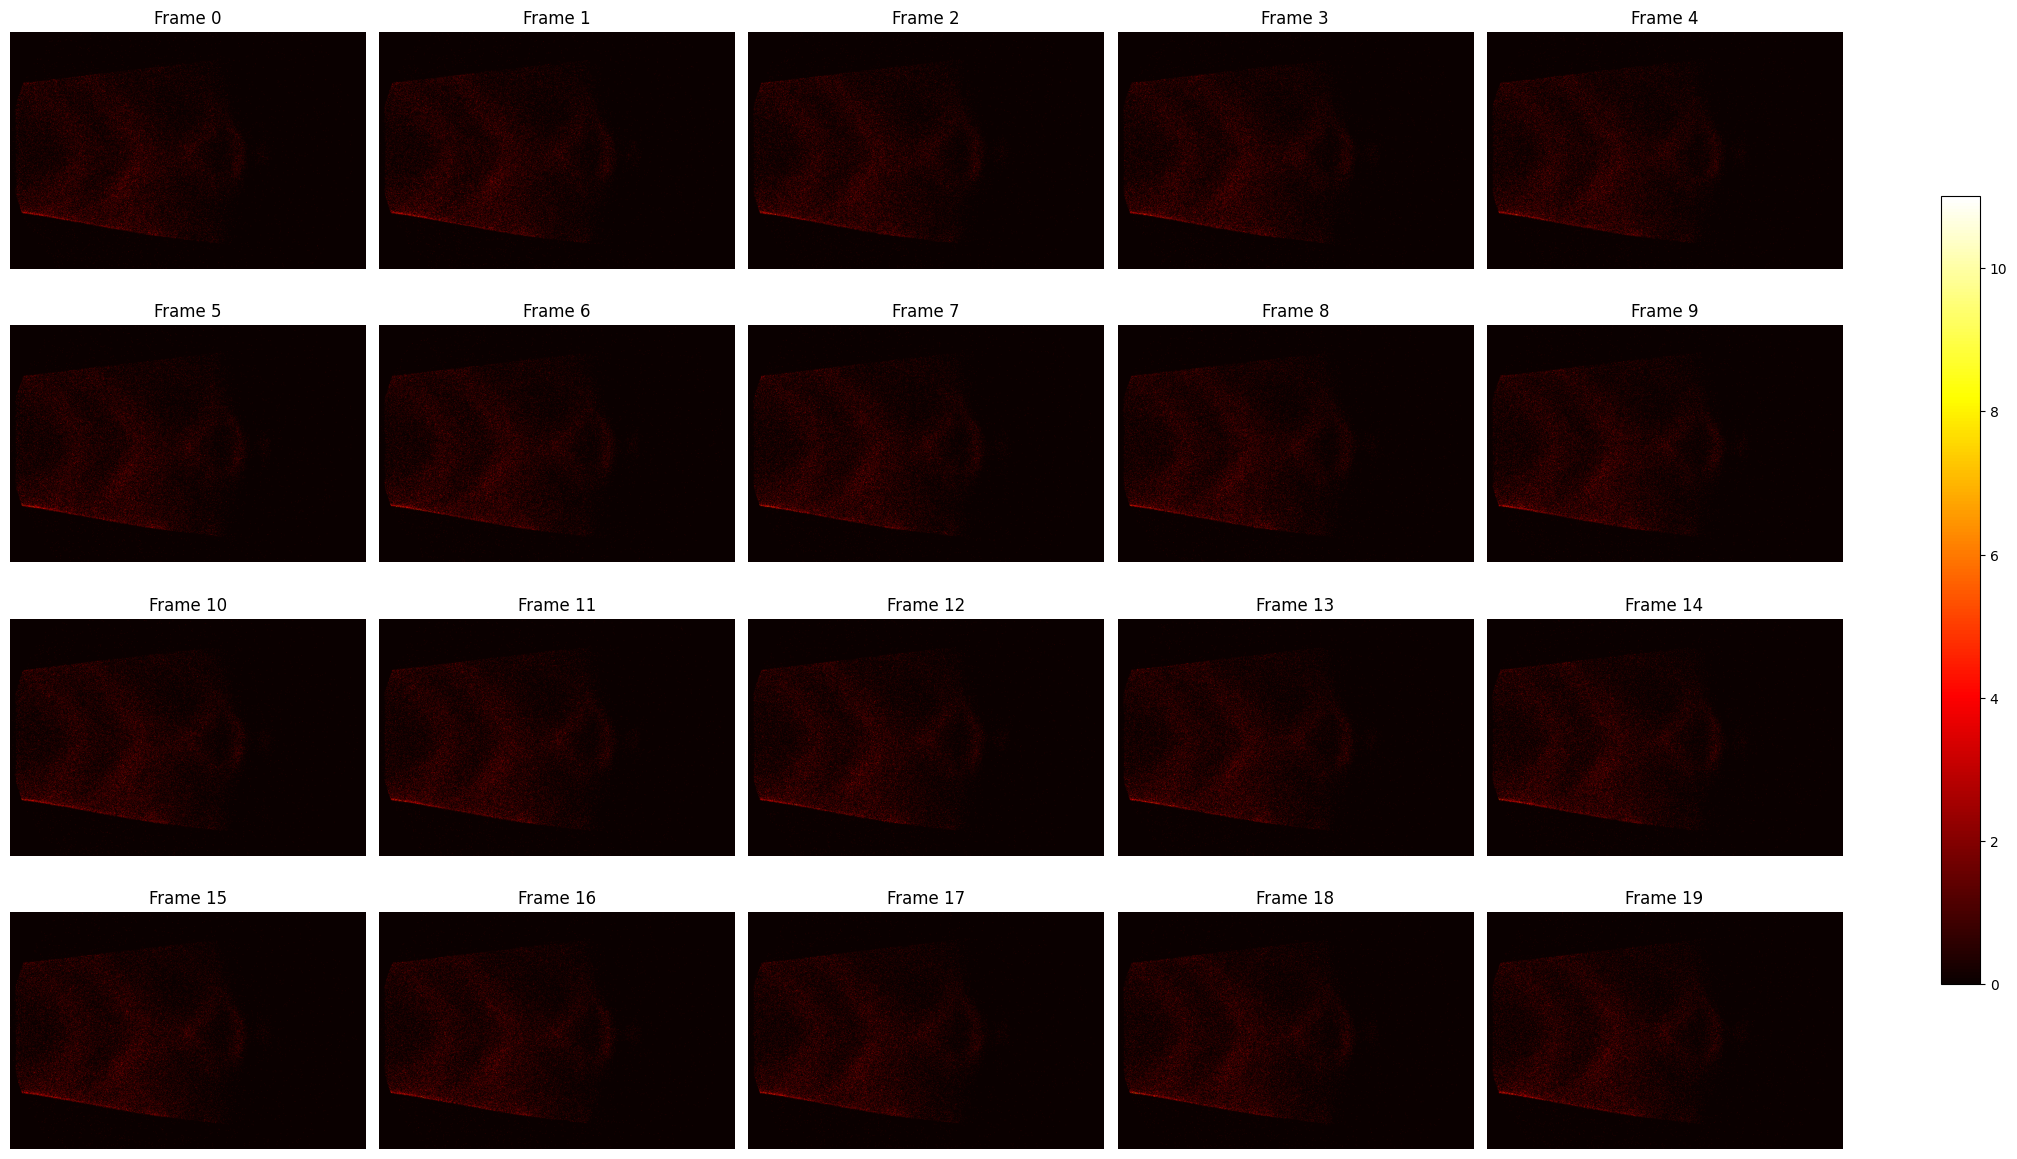

In [12]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

file_path = 'BiSe_232deg_38p7nm_static_6.h5'

with h5py.File(file_path, 'r') as f:
    # 1. Load data and remove the dimension of size 1
    # Shape goes from (20, 1, 576, 864) to (20, 576, 864)
    data = np.squeeze(f['scan0/image'][()])

    # 2. Create a 4x5 grid of plots
    fig, axes = plt.subplots(4, 5, figsize=(20, 12))
    axes = axes.flatten() # Flatten 2D array of axes for easy looping

    # 3. Plot each frame
    for i in range(20):
        # Use a high-contrast colormap since your max value is only 11
        im = axes[i].imshow(data[i], cmap='hot', vmin=0, vmax=11)
        axes[i].set_title(f"Frame {i}")
        axes[i].axis('off') # Hide x/y numbers for a cleaner look

    # 4. Add a single colorbar for the whole figure
    plt.tight_layout()
    fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.02, pad=0.05)
    plt.show()

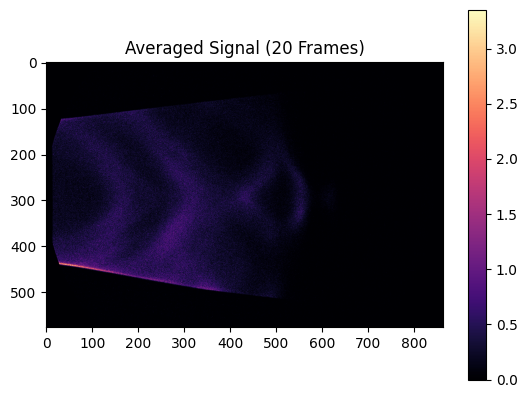

In [13]:
import numpy as np

with h5py.File(file_path, 'r') as f:
    # Load all frames and remove the useless '1' dimension
    # (20, 1, 576, 864) becomes (20, 576, 864)
    all_frames = f['scan0/image'][()].squeeze()
    
    # Average across the 20 frames
    avg_img = np.mean(all_frames, axis=0)
#axes[i].imshow(np.log1p(data[i]), cmap='hot')
    plt.imshow(avg_img, cmap='magma')
    plt.title("Averaged Signal (20 Frames)")
    plt.colorbar()
    plt.show()

In [14]:
# Change the imshow line to this:
axes[i].imshow(np.log1p(data[i]), cmap='hot')

In [15]:
# Integrate over the Energy axis (Vertical) to get Intensity vs Angle
# This replicates the 'Angular Distribution' used in GIXRF/GEXRF
angular_distribution = np.sum(cropped_img, axis=0)

# Integrate over the Angle axis (Horizontal) to see the Energy Spectrum
energy_spectrum = np.sum(cropped_img, axis=1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(energy_spectrum)
ax[0].set_title("Energy Spectrum (Core Level)")
ax[1].plot(angular_distribution)
ax[1].set_title("Angular Yield Distribution (Paper Analysis Input)")
plt.show()

NameError: name 'cropped_img' is not defined

Successfully created 'cropped_img' with shape: (352, 608)


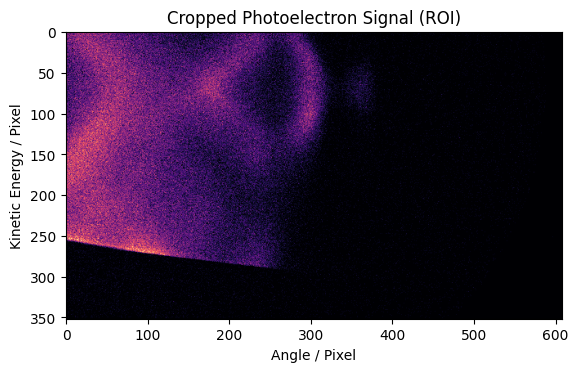

In [16]:
with h5py.File(file_path, 'r') as f:
    # Extract data: (20 repetitions, 1, 576 rows, 864 cols)
    # We squeeze to get (20, 576, 864) and average the 20 frames
    raw_frames = np.squeeze(f['scan0/image'][()])
    avg_img = np.mean(raw_frames, axis=0)
    
    # Extract ROI from attributes
    attrs = f['scan0'].attrs
    x1, x2 = attrs['roix1'], attrs['roix2']
    y1, y2 = attrs['roiy1'], attrs['roiy2']
    
    # Define cropped_img here
    cropped_img = avg_img[y1:y2, x1:x2]

print("Successfully created 'cropped_img' with shape:", cropped_img.shape)

# Visualize the cropped signal
plt.imshow(np.log1p(cropped_img), cmap='magma')
plt.title("Cropped Photoelectron Signal (ROI)")
plt.xlabel("Angle / Pixel")
plt.ylabel("Kinetic Energy / Pixel")
plt.show()

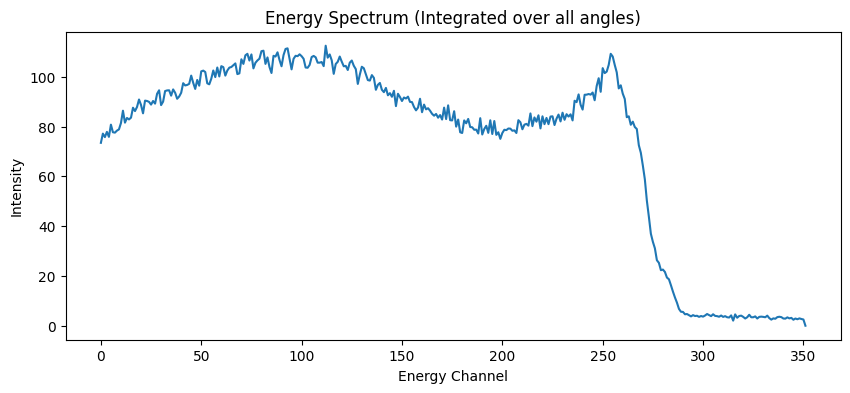

In [17]:
# The paper analyzes 'Yield'. In PES, this is the area under the energy peak.
# We sum over the vertical axis (Energy) to get the Angular Distribution
angular_yield = np.sum(cropped_img, axis=0)

# We sum over the horizontal axis (Angle) to see the Energy Spectrum
energy_spectrum = np.sum(cropped_img, axis=1)

plt.figure(figsize=(10, 4))
plt.plot(energy_spectrum)
plt.title("Energy Spectrum (Integrated over all angles)")
plt.xlabel("Energy Channel")
plt.ylabel("Intensity")
plt.show()